# VDS for SASSIE ECCO using Virtualizarr v2.x

This notebook aims to create two VDS's for the SASSIE ECCO project - one that combines all the daily collections into a single composite VDS, and another for the monthly collections. This notebook tests the use of pickling in the following workflow

1. Generate a combined VDS for each collection, saving the VDS as a pickled object on disk.
2. Open all pickled objects from disk, combine into composite VDS, and save as icechunk store.

#### Why pickling?
This workflow allows the collection-level VDS's to be created and saved without having to create all of them in one session. This is valuable because currently with Virtualizarr v2 we cannot get the `open_virtual_dataset()` function to parallelize - we run into credentialing errors. Further, it is not clear how to open an existing icechunk store and append to it - whether we are trying to 'merge' two separate collections (unclear if possible), or even for appending files from within the same collection (supposed to be possible at this time).

In [1]:
import pickle

# Built-in packages-----------------
import os
import sys
import shutil
import warnings
from typing import Optional

# Filesystem management-----------------
import earthaccess

import fsspec

from obstore.auth.earthdata import NasaEarthdataCredentialProvider
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry
import icechunk

# Data handling-----------------
import numpy as np
import xarray as xr
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser
import pandas as pd

# Parallel computing -----------------
# import multiprocessing
# from dask import delayed
# import dask.array as da
# from dask.distributed import Client
# import coiled

# Other-----------------
import matplotlib.pyplot as plt

## 1. Setup

In [2]:
# Get Earthdata creds
auth = earthaccess.login()

Enter your Earthdata Login username:  deanh808
Enter your Earthdata password:  ········


In [3]:
credentials_url = "https://archive.podaac.earthdata.nasa.gov/s3credentials"
bucket = "s3://podaac-ops-cumulus-protected"

In [4]:
credential_provider = NasaEarthdataCredentialProvider(credentials_url, auth=(auth.username, auth.password))
store = S3Store.from_url(bucket, credential_provider=credential_provider)
registry = ObjectStoreRegistry({bucket: store})

In [5]:
shortnames_daily = [
    "SASSIE_ECCO_L4_ATM_STATE_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_FRESH_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_HEAT_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_DENS_PRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_VOL_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_TEND_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_STRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_DIAGS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_BOUNDARY_LAYER_LLC1080GRID_DAILY_V1R1",
]

shortnames_monthly = [
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_SNAPSHOT_V1R1",
]

shortnames_other = [
    "SASSIE_ECCO_L4_GEOMETRY_LLC1080GRID_V1R1"    
]

## 2. Generate combined ref files for each collection and save as pickle

In [6]:
def open_vds_warnsupressed(datalink, **kwargs):
    """
    Just a wrapper around virtualizarr.open_virtual_dataset() but with a specific warning supressed.
    """
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Numcodecs codecs*", category=UserWarning)
        vds_ref = open_virtual_dataset(
                datalink, **kwargs
            )
    return vds_ref

In [7]:
def generate_combined_vds_ref(shortname, granule_info, registry):
    """
    """
    data_s3links = [g.data_links(access="direct")[0] for g in granule_info]
    
    ## Identify coord vars to pass to loadable_variables in virtualizarr -------------------
    grid_vars_reference = ['time', 'i', 'i_g', 'j', 'j_g', 'k', 'k_u', 'k_l', 'k_p1']
    data_sample = xr.open_dataset(earthaccess.open([granule_info[0]])[0])
    loadable_vars = []
    for c in list(data_sample.coords.keys()):
        if c in grid_vars_reference:
            loadable_vars.append(c)

    ## Create single file references ---------------------------------------------------------
    single_refs = []

    for s3l in data_s3links[:]:
        vds_ref_single = open_vds_warnsupressed(
            s3l,
            parser=HDFParser(),
            registry=registry,
            loadable_variables=loadable_vars,
            decode_times=False
        )
        single_refs.append(vds_ref_single)

    # Create the combined reference
    virtual_ref_combined = xr.combine_nested(
        single_refs, concat_dim=['time'], coords='minimal', 
        compat='override', combine_attrs='drop_conflicts'
    )

    return virtual_ref_combined

## 2.1 Monthly files

In [8]:
## Loop through collections and generate a combined VDS for each, saving each as a pickle:
vds_refs_combined = []

for sn in shortnames_monthly[:]:
    # Generate combined VDS:
    granule_info = earthaccess.search_data(
        short_name= sn,
    )
    vds_ref_combined = generate_combined_vds_ref(sn, granule_info, registry)

    # Pickle:
    pkl = pickle.dumps(vds_ref_combined, protocol=-1)
    filename_pickle = sn + '.pickle'
    with open(filename_pickle, 'wb') as handle:
        pickle.dump(pkl, handle, protocol=pickle.HIGHEST_PROTOCOL)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


## 2.2 Daily files

In [ ]:
## Loop through collections and generate a combined VDS for each, saving each as a pickle:
vds_refs_combined_daily = []

for sn in shortnames_daily[:]:
    # Generate combined VDS:
    granule_info = earthaccess.search_data(
        short_name= sn,
    )
    vds_ref_combined = generate_combined_vds_ref(sn, granule_info, registry)

    # Pickle:
    pkl = pickle.dumps(vds_ref_combined, protocol=-1)
    filename_pickle = sn + '.pickle'
    with open(filename_pickle, 'wb') as handle:
        pickle.dump(pkl, handle, protocol=pickle.HIGHEST_PROTOCOL)

## 3. Merge the combined reference files into a super VDS Icechunk store

## 3.1 Monthly data

#### Merge VDS's

In [18]:
# Reopen pickled files:
vds_pkl_list = []

for sn in shortnames_monthly[:]:
    fname = sn + '.pickle'

    with open(fname, 'rb') as handle:
        temp_pkl = pickle.load(handle)
    vds_pkl_list.append(pickle.loads(temp_pkl))

In [20]:
# Combine all into single VDS:
composite_vds_monthly = xr.combine_nested(
    vds_pkl_list, concat_dim=None, 
    compat='override', combine_attrs='drop_conflicts'
)

#### Save to Icechunk store

In [21]:
def create_icechunk_repo_local(repo_name: str):
    """
    Creates an icechunk repository locally.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=bucket+"/",
            store=icechunk.s3_store(region="us-west-2", anonymous=True)
        )
    )
    return icechunk.Repository.create(storage, config)

In [35]:
# Create icechunk repo and session
repo = create_icechunk_repo_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL.icechunk")
session = repo.writable_session("main")

  2026-02-27T01:00:29.365083Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:81



In [36]:
# Then write the super VDS to the store:
composite_vds_monthly.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'7VZ55Y8GDF7J2T3VXB7G'

## 4. Test combined reference file

In [37]:
def open_icechunk_store_local(store_path: str, datafile_bucket: str, s3_creds: Optional[dict] = None):
    """
    Accesses a local icechunk repo and optionally appends Earthdata credentials to it.

    Inputs
    ------
    * repo_path (str): Path to icechunk repo.
    * s3_creds (dict, optional): Should contain values for 'accessKeyId', 'secretAccessKey', and 
        'sessionToken'.
    """
    
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            datafile_bucket + "/",
            icechunk.s3_store(region="us-west-2"),
        )
    )
    
    # Get temporary S3 credentials for reading the actual data:
    credentials = icechunk.containers_credentials({
        datafile_bucket + "/": icechunk.s3_credentials(
            access_key_id=s3_creds["accessKeyId"],
            secret_access_key=s3_creds["secretAccessKey"],
            session_token=s3_creds["sessionToken"],
        )
    })
    
    # Open the existing repository:
    storage = icechunk.local_filesystem_storage(store_path)
    repo = icechunk.Repository.open(
        storage=storage,
        config=config,
        authorize_virtual_chunk_access=credentials,
    )

    session = repo.readonly_session(branch="main")
    return session.store

In [25]:
earthaccess.login()

In [38]:
s3_creds = earthaccess.get_s3_credentials(daac="PODAAC")
#store_daily = open_icechunk_store_local("SASSIE_ECCO_DAILY_ALL.icechunk", bucket, s3_creds)
store_monthly = open_icechunk_store_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL.icechunk", bucket, s3_creds)

  2026-02-27T01:00:37.715921Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:81



In [39]:
%%time
## Use it to open data on Earthdata:
data = xr.open_zarr(
    store_monthly,
    zarr_format=3,
    consolidated=False,
    chunks={},
)
data

CPU times: user 58.2 ms, sys: 8.46 ms, total: 66.6 ms
Wall time: 57.9 ms


/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, k: 90, j_g: 1080, i_g: 1800, nv: 2,
               k_l: 90, k_u: 90, nb: 4, k_p1: 91)
Coordinates: (12/22)
    XV        (j_g, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YC        (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YV        (j_g, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    Z_bnds    (k, nv) float32 720B dask.array<chunksize=(90, 2), meta=np.ndarray>
    ...        ...
  * k         (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k_p1      (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89 90
  * time      (time) datetime64[ns] 680B 2014-02-01 2014-03-01 ... 2021-02-01
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * k_l       (k_l) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * k_u       (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
Dimensions without coordinates: nv, nb
Data variables:
    ETAN      (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SALT      (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIarea    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIheff    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIhsnow   (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    THETA     (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIvice    (time, j_g, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    PHIBOT    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIuice    (time, j, i_g) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad  (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/45)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          PT0S
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

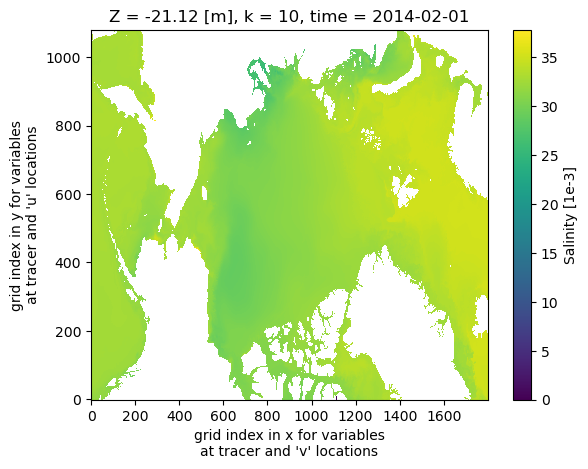

In [40]:
data["SALT"].isel(time=0, k=10).plot()

## Try to create an HTTPS version

In [105]:
def local_to_s3_url(old_local_path: str) -> str:
    from pathlib import Path

    new_s3_bucket_url = "http://s3.amazonaws.com/my_bucket/"

    filename = Path(old_local_path).name
    return str(new_s3_bucket_url / filename)

In [ ]:
#renamed_vds = vds.vz.rename_paths(local_to_s3_url)